In [1]:
import os
import sys
import shutil
import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.nn.functional as F


from tqdm import tqdm, trange

import warnings


from ml_collections import ConfigDict

In [2]:
sys.path.append('..')

In [3]:



from CRT_utils.CRT.core.dataset import COCODataset, COCODatasetCustom



In [4]:
dataset = COCODatasetCustom(
    '../datasets/COCO18_dset_for_CRT_training/coco18_newtrain.json', 
    '../datasets/COCO18_dset_for_CRT_training/coco18_for_crt', 
    image_size      = (224,224), 
    # _____ ORIGINAL CODE _____
    normalize_means = [0.485, 0.456, 0.406], 
    normalize_stds  = [0.229, 0.224, 0.225],
    # _____ ORIGINAL CODE _____
    
    # _____ MODIFIED VERSION _____
#     normalize_means = [0.5, 0.5, 0.5], 
#     normalize_stds  = [0.5, 5, 0.5]
    # _____ MODIFIED VERSION _____
    
    # _____ ADDED CODE _____
    category_dic_dir = '../datasets/COCO18_dset_for_CRT_training/category_idx_dict.pkl'
    
    # _____ ADDED CODE _____
    
)

-------------------------------
Annotation Counts
-------------------------------
potted plant               8631
tv                         5803
bottle                    24070
chair                     38073
car                       43533
stop sign                  1983
clock                      6320
cup                       20574
fork                       5474
knife                      7760
bowl                      14323
toilet                     4149
laptop                     4960
mouse                      2261
keyboard                   2854
microwave                  1672
oven                       3334
sink                       5609
Total                    201383
-------------------------------



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-11.291612..9.92889].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-11.291612..9.92889].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data

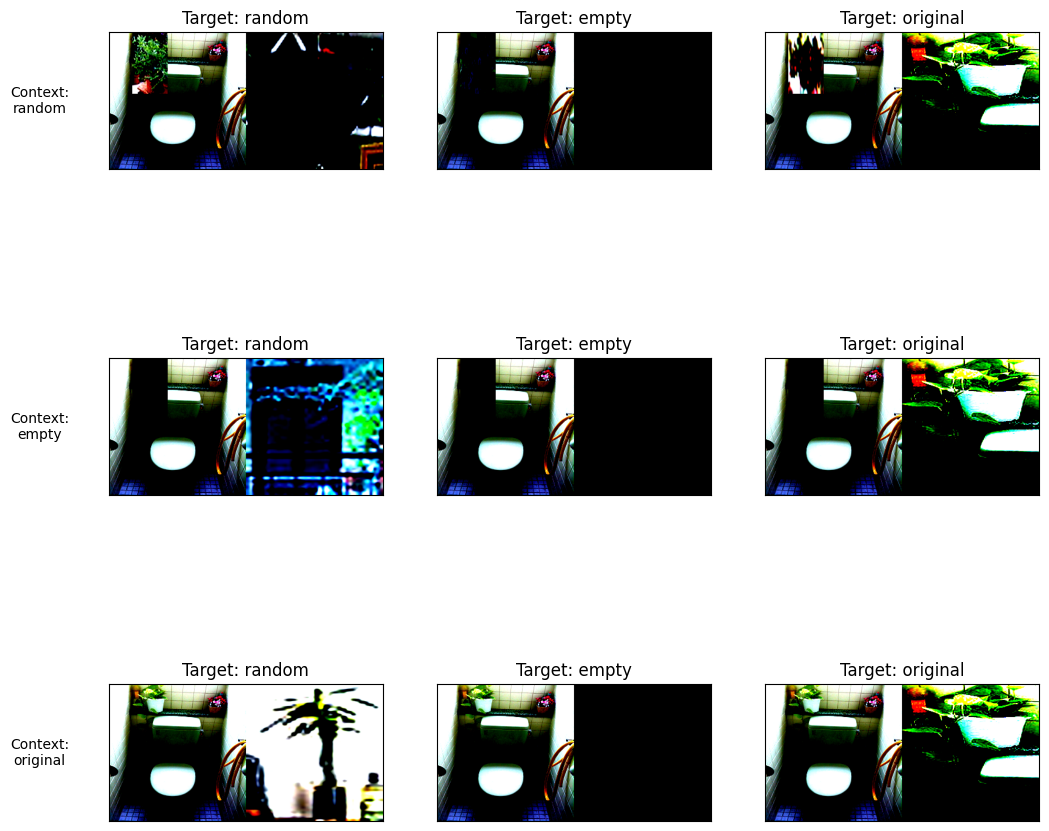

In [16]:

dataset_idx = 2




choice_labels = {
    0: "random",
    1: "empty",
    2: "original"
}

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for context_choice in range(3):

    for target_choice in range(3):

        dataset.context_choice = context_choice
        dataset.target_choice  = target_choice

        # context image
        context_img = dataset[dataset_idx][0].permute(1, 2, 0)

        # target image
        target_img = dataset[dataset_idx][1].permute(1, 2, 0)

        # combine side-by-side
        combined_img = torch.cat([context_img, target_img], dim=1)

        ax = axes[context_choice, target_choice]
        ax.imshow(combined_img)

        # column title
        ax.set_title(f"Target: {choice_labels[target_choice]}")

        # row label
        if target_choice == 0:

            ax.set_ylabel(
                f"Context:\n{choice_labels[context_choice]}",
                rotation=0,
                labelpad=50,
                va='center'
            )

        ax.set_xticks([])
        ax.set_yticks([])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


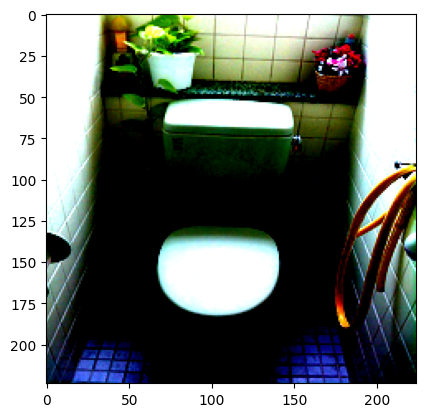

In [19]:



plt.imshow(dataset[dataset_idx][0].permute(1,2,0))







Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-11.291612..9.92889].


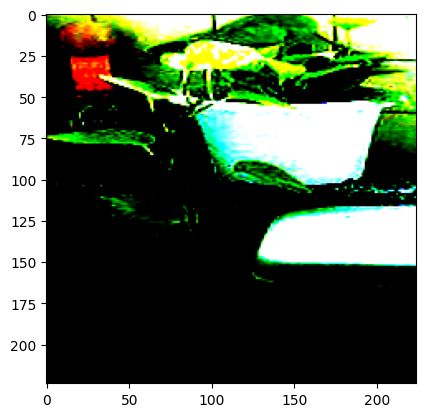

In [18]:
plt.imshow(dataset[dataset_idx][1].permute(1,2,0))